# مقدمة ل SIFT - تحويل الخصائص الغير متأثر بالقياس:

### الهدف:

** في هذا الفصل: **

* سنتعلم مفهوم خوارزمية SIFT .

* سنتعلم ايجاد نقاط SIFT وموصفاتها.

### النظرية:

في ما مضى رأينا أن الخصائص تبقى كذلك وحتى بعد التدوير , اي انها لاتتأثر بالتدوير , ولكن بالنسبة لتغيير الحجم فقد لا يصح هذا أي أن الزاوية لاتبقى كذلك بعد التغيير , ومنه نقول أن مكتشفات هاريس متأثرة بالحجم.


ولذلك تم انشاء خوارزمية مناسبة لايجاد النقاط وفق هذه الحالة وهي SIFT وتتألف هذه الخوارزمية نظرياً من 4 مراحل:

**#1. اكتشاف القيم العظمى للفضاء القياسي:**

نلاحظ مما سبق أنه لا يمكننا استخدام نفس القناع لاكتشاف زوايا مختلفة بالحجم , ولذلك نلجأ لاستخدام لابلاسي الغاوسي LoG وذلك من أجل قيم مختلفة للقناع الغاوسي ل $\sigma$ ومع تغيير قيمتها نكتشف الزوايا بالاحجام المختلفة , 

ولكن هذه العملية مكلفة حسابياً لذلك نلجأ لاستخدام الفرق الغاوسي بخوارزمية SIFT  والذي يعد أبسط ولكن يقوم بالمهمة وذلك عن طريق طرح المستويات في الهرم الغاوسي من أجل قيم ثمانية مختلفة لكل منها كما الصورة

<img src="../../images/less22.png">

وبعد ايجاد ما سبق DoG يتم البحث عن قيمة محلية عظمى وعلى المستويات المختلفة وفي حال وجودها تكون زاوية محتملة .  

وبالنظر لبارامترات مختلفة , تعطي الورقة بعض البيانات التجريبية لنتائج أفضل .

**#2. تحديد النقاط للزوايا :**

عندما نوجد النقاط المحتملة للزوايا , يجب تصفيتها لاستخلاص النقاط الاكثر احتمالاً ويتم هذا بمساعدة منشور تايلور , وذلك عبر عتبة معينة للقيم العظمى , وتدعى هذه العتبة **constrastThreshold ** .

وبما أن DoG لديها حساسية للحواف لذلك يجب ازالتها حيث هنا يتم استخدام مفهوم مشابه لمكتشفات هاريس , وذلك بمصفوفة تقارن القيم الذاتية للنقاط , واذا كان الناتج أكبر من عتبة معينة تدعى **edgeThreshold ** في OpenCV فانه يتم شطب النقطة , ونموذجياً كانت 10 في الورقة الاصلية .

ولذلك بعد كل هذا فان ما يبقى هو النقاط المهمة القوية .

**#3 اسناد زواية دوران: **

يتم اسناد قيم دوران للنقاط المكتشفة , بأخذ جوار محدد والطويلة والاتجاه تحسب لاجله ,  والزاوية تحدد بهستوغرام له 36 قطباً والذروة الاعلى تمثل الاتجاه , وكذلك اي ذروة تمثل بنسبة أكبر من 80% منها تعتبر نقطة مضاعفة بنفس المكان والحجم  .

**#4 موصفات النقاط : **

وهنا يتم انشاء الموصفات وهي بحجم 16X16 حول النقطة . ويتم تقسيمها ل 16 مربع فرعي بحجم 4 X 4 . ولكل منها هناك هستوغرام ب 8 أقطاب للدوران , ومنه يوجد  128 قطباً للقناع الكلي . تمثل كلها كشعاع يعطي الموصف بالاضافة لقياسات أخرى تعطيه تمثيلاً ثابتاً مع تغيرات الاضاءة والدوران.

**#5 مطابقة النقاط : **

لمطابقة الخصائص بين صورتين يتم اخذ الجوار لكل منهما . ولكن ببعض الحالات قد يكون هناك مطابقان اثنان قريبان لبعضهما , وهذا قد يحدث نتيجة الضجيج , وهنا نأخذ نسبة المسافة الاقرب لكل منهما عن النقطة المراد مطابقتها , فاذا كانت أكبر من 0.8 عندها نرفض النتيجة , وهذا يزيل 90 % من النتائج الخاطئة حسب الورقة .


هذه هي خلاصة الخوارزمية ولتفاصيل أكثر يمكن العودة للورقة الاصلية , 

تذكر هذه الخوارزمية لها حقوق نشر , لذلك هي بالقسم الغير مجاني من OpenCV.

### SIFT في OpenCV:

ولنرى التطبيق في OpenCV , اولاً علينا بناء جسم SIFT  . لنرسم النقاط ونكتشفها .  بمكننا تمرير بارامترات كثيرة له , كيفية ومشروحة جيداً في التوثيق.


In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

img = cv2.imread('wt.jpg')
# for matplotlib
img= cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Build SIFT
sift = cv2.SIFT()
kp = sift.detect(gray,None)

res_img=cv2.drawKeypoints(gray,kp)

**sift.detect ** يوجد النقاط بالصورة ويمكن تمرير قناع له لمنطفة محددة , 

وكل نقطة هي تركيب خاص له خصائص مثل احداثياته , حجم الجوار ذو المعنى , الزاوية , الاستجابة المحددة و لقوة النقطة .

ولدى OpenCV  تابع **cv2.drawKeypoints ** ,والذي يرسم دوائر صغيرة حول الخصائص وفي حال مررنا له العلم , ** cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ** سيرسم دوائر متناسبة مع القوة وبالاتجاه للخاصية . , انظر للمثال التالي , وقارن:

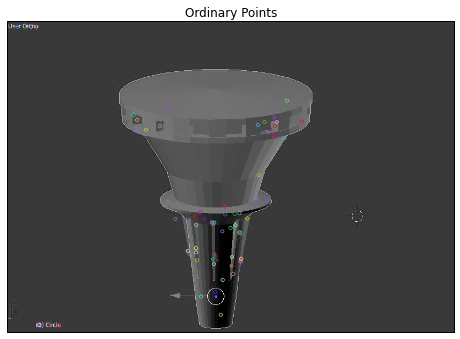

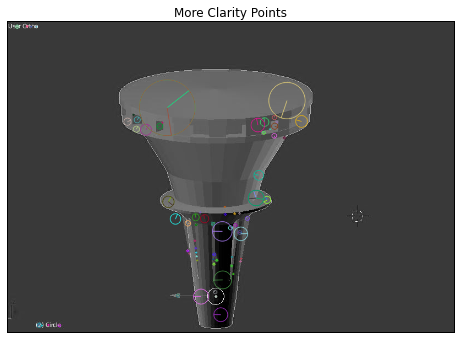

In [10]:
plt.figure(figsize=(8,16))
plt.imshow(res_img)
plt.xticks([])
plt.yticks([])
plt.title('Ordinary Points')
plt.show()

res2_img=cv2.drawKeypoints(
    gray,kp,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(8,16))
plt.imshow(res2_img)
plt.xticks([])
plt.yticks([])
plt.title('More Clarity Points')
plt.show()


الان لحساب الموصفات , هناك طريقتان في OpenCV :

1. بما أننا أوجدنا مسبقاً النقاط , يمكننا استدعاء **sift.compute ** والذي يحسب الموصفات من النقاط التي أوجدناها , مثلاً : `kp,des=dift.compute(gray,kp)`

2. إذا لم توجد النقاط , مباشرة أوجد النقاط والموصفات بتابع واحد بخطوة واحدة بالتابع , **sift.detectAndCompute ** 

وكمثال للطريقة الثانية نكتب:

In [11]:
sift = cv2.SIFT()
kp, des = sift.detectAndCompute(gray,None)

وهنا kp ستكون قائمة من النقاط و des هي مصفوفة numpy  من الشكل : عدد النقاط X128  .

والان الخطوة التالية هي مطابقة الخصائص و الموصفات , وهذا سيأتي بفصول لاحقة .

### مراجع إضافية :

### تمارين:
